In [1]:
import pandas as pd
import plotly.graph_objects as go

print("Imports successful")

Imports successful


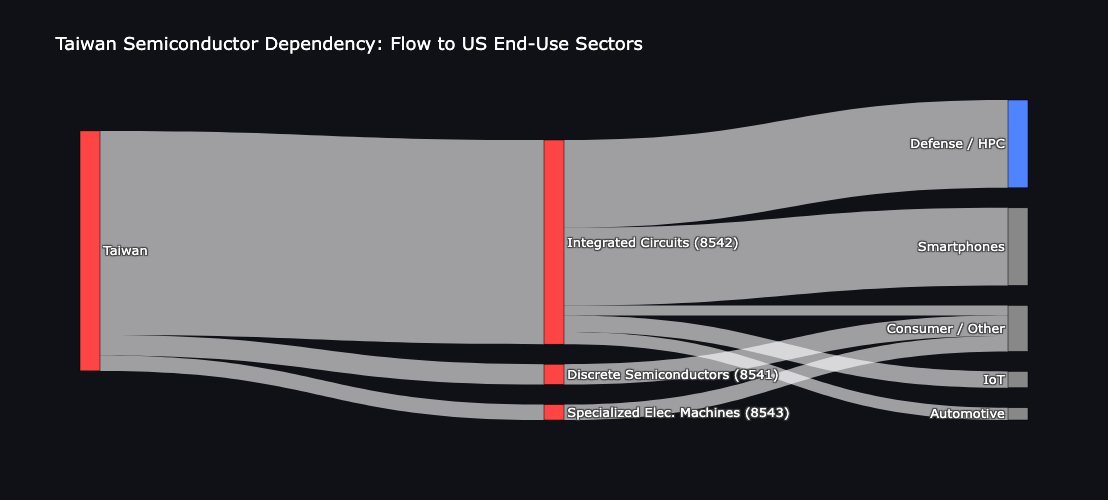

In [2]:
df_baseline = pd.read_csv('data/taiwan_baseline.csv')

# Define nodes
node_labels = [
    'Taiwan',                        # 0
    'Integrated Circuits (8542)',     # 1
    'Discrete Semiconductors (8541)', # 2
    'Specialized Elec. Machines (8543)', # 3
    'Defense / HPC',                 # 4
    'Smartphones',                   # 5
    'IoT',                           # 6
    'Automotive',                    # 7
    'Consumer / Other'               # 8
]

node_colors = [
    '#ff4444',  # Taiwan - red
    '#ff4444',  # 8542 - red
    '#ff4444',  # 8541 - red
    '#ff4444',  # 8543 - red
    '#4f83ff',  # Defense - blue
    '#888888',  # Smartphones - gray
    '#888888',  # IoT - gray
    '#888888',  # Automotive - gray
    '#888888',  # Consumer - gray
]

ic = 8.883
disc = 0.883
spec = 0.674

sources = [0, 0, 0, 1, 1, 1, 1, 1, 2, 3]
targets = [1, 2, 3, 4, 5, 6, 7, 8, 8, 8]
values  = [
    ic, disc, spec,
    ic * 0.43,
    ic * 0.38,
    ic * 0.08,
    ic * 0.06,
    ic * 0.05,
    disc,
    spec,
]

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text='Taiwan Semiconductor Dependency: Flow to US End-Use Sectors',
    font_size=13,
    paper_bgcolor='#0f1117',
    font_color='white',
    height=500
)

fig.show()

In [3]:
fig.write_html('output/chart1_sankey.html', include_plotlyjs=True)
print("Exported chart1_sankey.html")

Exported chart1_sankey.html


In [4]:
import plotly.express as px

df_scenarios = pd.read_csv('data/scenario_output.csv')
print(df_scenarios)

  scenario  hts_code                    chip_category  \
0   30-day      8541          Discrete Semiconductors   
1   30-day      8542              Integrated Circuits   
2   30-day      8543  Specialized Electrical Machines   
3   60-day      8541          Discrete Semiconductors   
4   60-day      8542              Integrated Circuits   
5   60-day      8543  Specialized Electrical Machines   
6   90-day      8541          Discrete Semiconductors   
7   90-day      8542              Integrated Circuits   
8   90-day      8543  Specialized Electrical Machines   

   taiwan_import_share_pct  disruption_rate  inventory_buffer_factor  \
0                      3.9             0.40                     0.50   
1                     23.3             0.40                     0.50   
2                      4.0             0.40                     0.50   
3                      3.9             0.65                     0.25   
4                     23.3             0.65                     0.25 

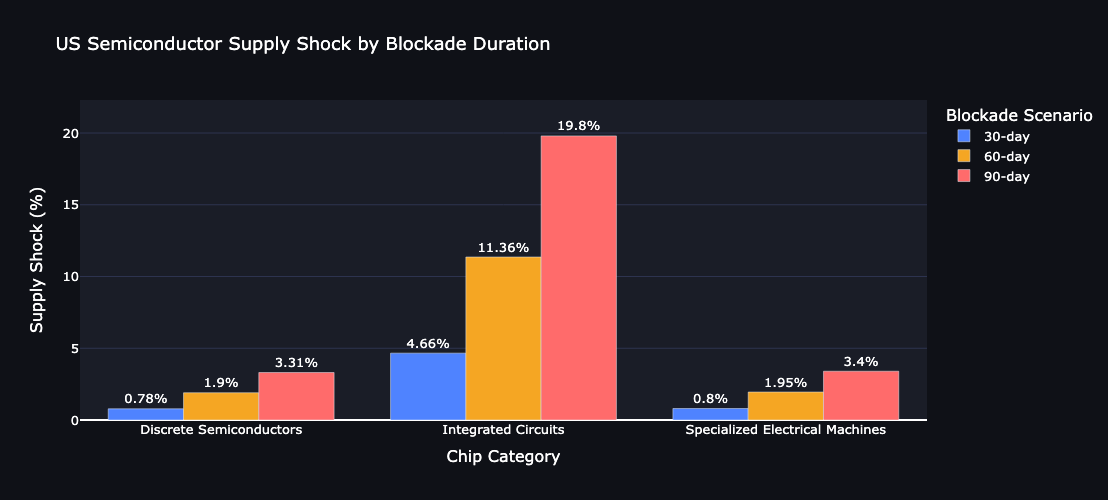

In [5]:
fig2 = px.bar(
    df_scenarios,
    x='chip_category',
    y='supply_shock_pct',
    color='scenario',
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    labels={
        'chip_category': 'Chip Category',
        'supply_shock_pct': 'Supply Shock (%)',
        'scenario': 'Blockade Scenario'
    },
    color_discrete_map={
        '30-day': '#4f83ff',
        '60-day': '#f5a623',
        '90-day': '#ff6b6b'
    },
    text='supply_shock_pct'
)

fig2.update_traces(texttemplate='%{text}%', textposition='outside')

fig2.update_layout(
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=500,
    yaxis_title='Supply Shock (%)',
    xaxis_title='Chip Category',
    legend_title='Blockade Scenario',
    yaxis=dict(gridcolor='#2e3450')
)

fig2.show()

In [6]:
fig2.write_html('output/chart2_scenarios.html', include_plotlyjs=True)
print("Exported chart2_scenarios.html")

Exported chart2_scenarios.html


In [7]:
df_defense = pd.read_csv('data/defense_exposure.csv')
print(df_defense.head())

                                        program_name  naics_code  \
0                                   RAYTHEON COMPANY      334511   
1                        LOCKHEED MARTIN CORPORATION      334511   
2               NORTHROP GRUMMAN SYSTEMS CORPORATION      334511   
3  BAE SYSTEMS INFORMATION AND ELECTRONIC SYSTEMS...      334511   
4                        TEXTRON SYSTEMS CORPORATION      334511   

                                   naics_description  contract_value_usd  \
0  SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...        4.340387e+10   
1  SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...        2.975899e+10   
2  SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...        1.517938e+10   
3  SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...        6.878176e+09   
4  SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...        5.590076e+09   

   taiwan_dependency_pct  exposure_score  
0                  0.233    1.011310e+10  
1                  0.233    6.933846e+09  
2    

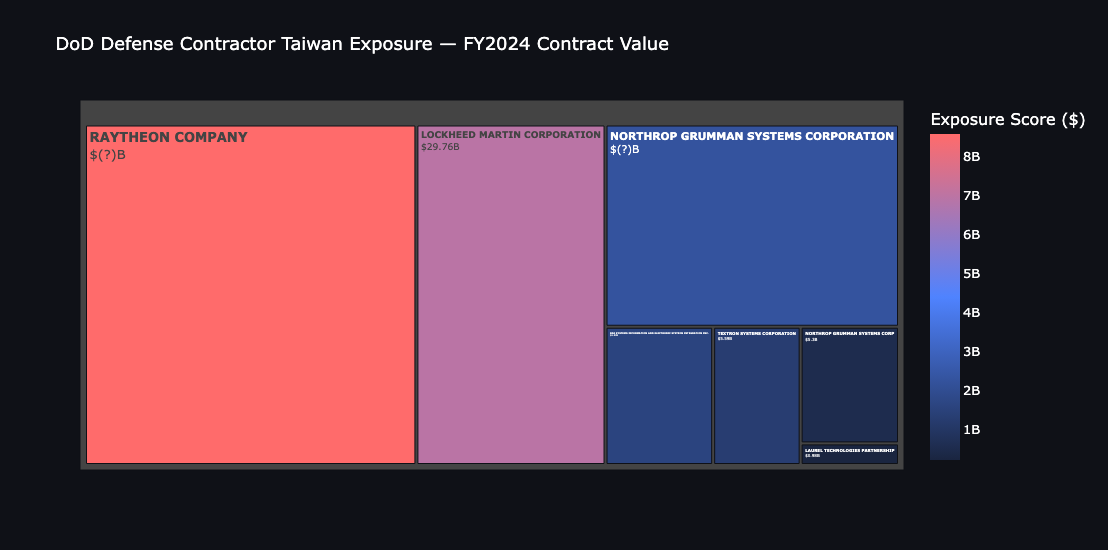

In [8]:
# Format values for display
df_defense['contract_value_billions'] = (df_defense['contract_value_usd'] / 1e9).round(2)
df_defense['exposure_billions'] = (df_defense['exposure_score'] / 1e9).round(2)
df_defense['taiwan_dependency_pct_display'] = (df_defense['taiwan_dependency_pct'] * 100).round(1)

fig3 = px.treemap(
    df_defense,
    path=['program_name'],
    values='contract_value_usd',
    color='exposure_score',
    color_continuous_scale=['#1a2540', '#4f83ff', '#ff6b6b'],
    title='DoD Defense Contractor Taiwan Exposure — FY2024 Contract Value',
    custom_data=['contract_value_billions', 'exposure_billions', 
                 'taiwan_dependency_pct_display', 'naics_description']
)

fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{customdata[0]}B',
    hovertemplate='<b>%{label}</b><br>' +
                  'Contract Value: $%{customdata[0]}B<br>' +
                  'Taiwan Exposure Score: $%{customdata[1]}B<br>' +
                  'Taiwan Dependency: %{customdata[2]}%<br>' +
                  'NAICS: %{customdata[3]}<extra></extra>'
)

fig3.update_layout(
    paper_bgcolor='#0f1117',
    font_color='white',
    font_size=13,
    height=550,
    coloraxis_colorbar=dict(title='Exposure Score ($)')
)

fig3.show()

In [9]:
df_defense['contract_value_billions'] = (df_defense['contract_value_usd'] / 1e9).round(2).astype(str)

fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{customdata[0]}B',
)

# Check what's in customdata
print(df_defense[['program_name', 'contract_value_billions', 'exposure_billions']].head())

                                        program_name contract_value_billions  \
0                                   RAYTHEON COMPANY                    43.4   
1                        LOCKHEED MARTIN CORPORATION                   29.76   
2               NORTHROP GRUMMAN SYSTEMS CORPORATION                   15.18   
3  BAE SYSTEMS INFORMATION AND ELECTRONIC SYSTEMS...                    6.88   
4                        TEXTRON SYSTEMS CORPORATION                    5.59   

   exposure_billions  
0              10.11  
1               6.93  
2               3.54  
3               1.60  
4               1.30  


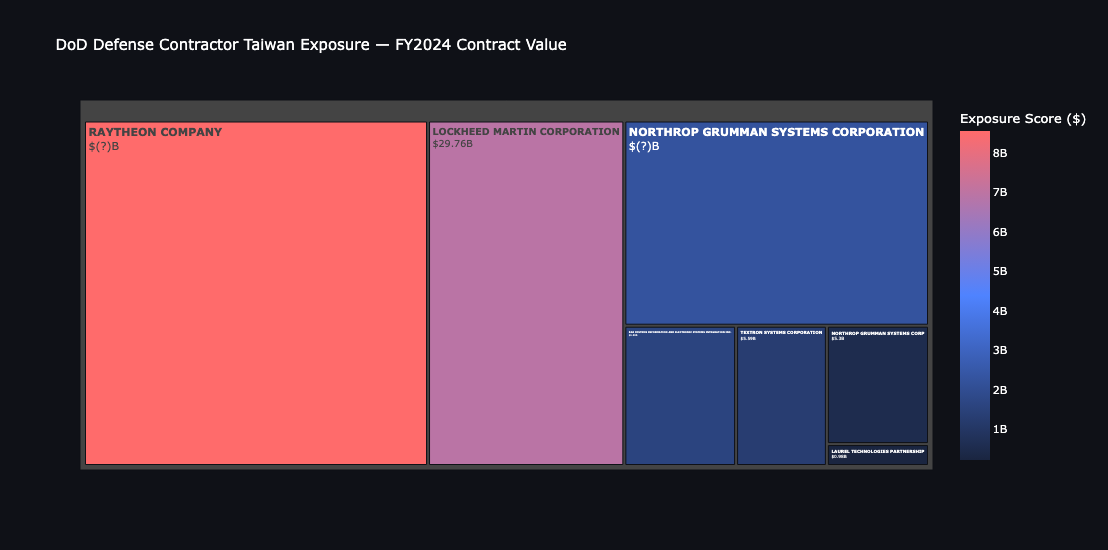

In [10]:
fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{customdata[0]}B',
    textfont=dict(size=11),
    hovertemplate='<b>%{label}</b><br>' +
                  'Contract Value: $%{customdata[0]}B<br>' +
                  'Taiwan Exposure Score: $%{customdata[1]}B<br>' +
                  'Taiwan Dependency: %{customdata[2]}%<br>' +
                  'NAICS: %{customdata[3]}<extra></extra>'
)

fig3.update_layout(
    paper_bgcolor='#0f1117',
    font_color='white',
    font_size=11,
    height=550,
    coloraxis_colorbar=dict(title='Exposure Score ($)')
)

fig3.show()

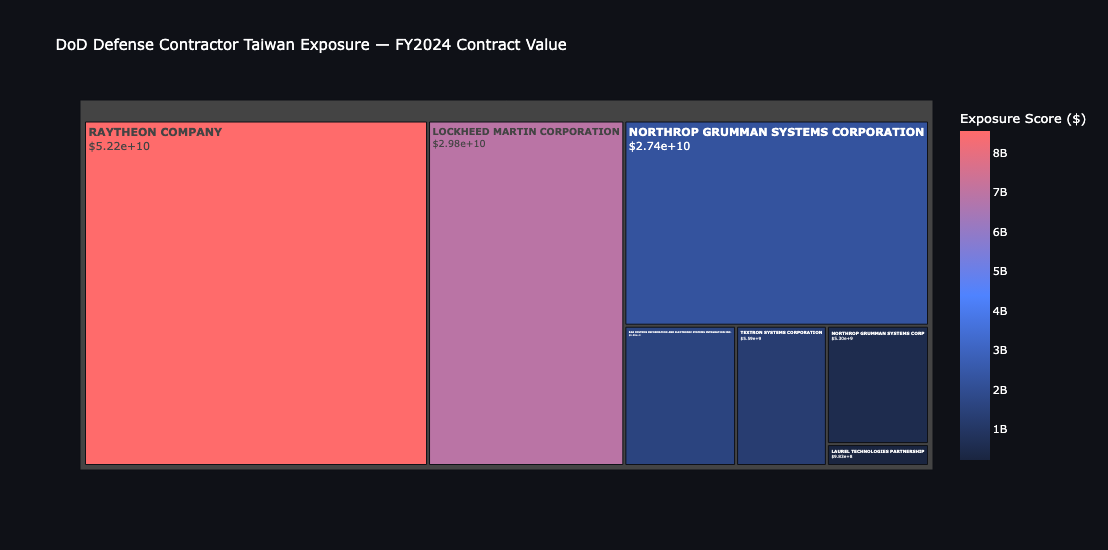

In [11]:
fig3 = px.treemap(
    df_defense,
    path=['program_name'],
    values='contract_value_usd',
    color='exposure_score',
    color_continuous_scale=['#1a2540', '#4f83ff', '#ff6b6b'],
    title='DoD Defense Contractor Taiwan Exposure — FY2024 Contract Value',
    custom_data=['contract_value_billions', 'exposure_billions',
                 'taiwan_dependency_pct_display', 'naics_description'],
    hover_data=None
)

fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{value:.2e}',
    textfont=dict(size=11),
    hovertemplate='<b>%{label}</b><br>' +
                  'Contract Value: $%{customdata[0]}B<br>' +
                  'Exposure Score: $%{customdata[1]}B<br>' +
                  'Taiwan Dependency: %{customdata[2]}%<br>' +
                  'NAICS: %{customdata[3]}<extra></extra>'
)

fig3.update_layout(
    paper_bgcolor='#0f1117',
    font_color='white',
    font_size=11,
    height=550,
    coloraxis_colorbar=dict(title='Exposure Score ($)')
)

fig3.show()

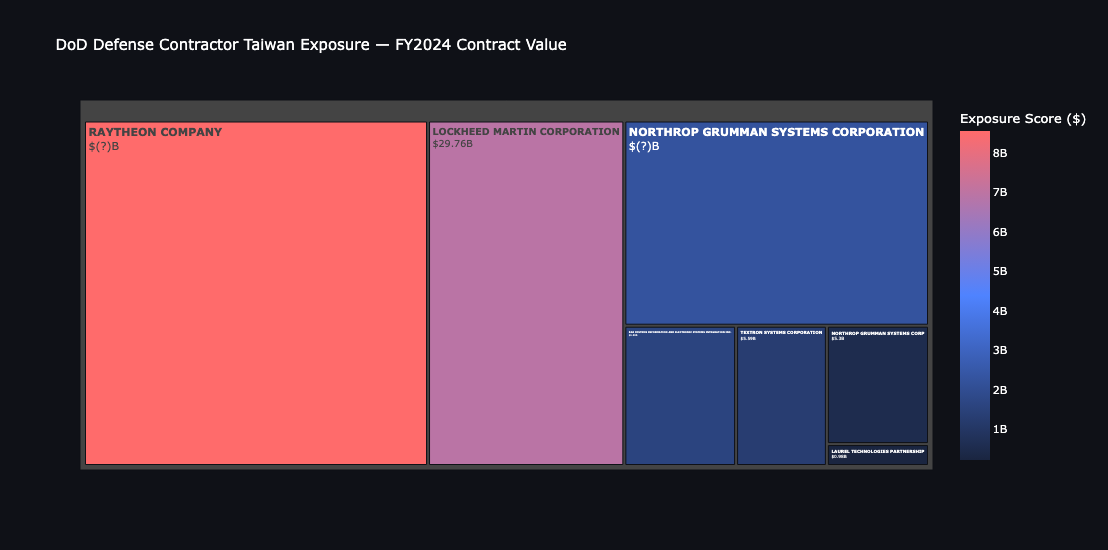

In [12]:
df_defense['contract_value_billions'] = (df_defense['contract_value_usd'] / 1e9).round(2)
df_defense['exposure_billions'] = (df_defense['exposure_score'] / 1e9).round(2)
df_defense['taiwan_dependency_pct_display'] = (df_defense['taiwan_dependency_pct'] * 100).round(1)

fig3 = px.treemap(
    df_defense,
    path=['program_name'],
    values='contract_value_usd',
    color='exposure_score',
    color_continuous_scale=['#1a2540', '#4f83ff', '#ff6b6b'],
    title='DoD Defense Contractor Taiwan Exposure — FY2024 Contract Value',
    custom_data=['contract_value_billions', 'exposure_billions',
                 'taiwan_dependency_pct_display', 'naics_description']
)

fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{customdata[0]}B',
    textfont=dict(size=11),
    hovertemplate='<b>%{label}</b><br>' +
                  'Contract Value: $%{customdata[0]}B<br>' +
                  'Exposure Score: $%{customdata[1]}B<br>' +
                  'Taiwan Dependency: %{customdata[2]}%<br>' +
                  'NAICS: %{customdata[3]}<extra></extra>'
)

fig3.update_layout(
    paper_bgcolor='#0f1117',
    font_color='white',
    font_size=11,
    height=550,
    coloraxis_colorbar=dict(title='Exposure Score ($)')
)

fig3.show()

In [13]:
print(df_defense[['program_name', 'contract_value_billions', 'exposure_billions', 'taiwan_dependency_pct_display']].to_string())

                                                      program_name  contract_value_billions  exposure_billions  taiwan_dependency_pct_display
0                                                 RAYTHEON COMPANY                    43.40              10.11                           23.3
1                                      LOCKHEED MARTIN CORPORATION                    29.76               6.93                           23.3
2                             NORTHROP GRUMMAN SYSTEMS CORPORATION                    15.18               3.54                           23.3
3  BAE SYSTEMS INFORMATION AND ELECTRONIC SYSTEMS INTEGRATION INC.                     6.88               1.60                           23.3
4                                      TEXTRON SYSTEMS CORPORATION                     5.59               1.30                           23.3
5                                                 RAYTHEON COMPANY                     8.75               0.87                           10.0
6     

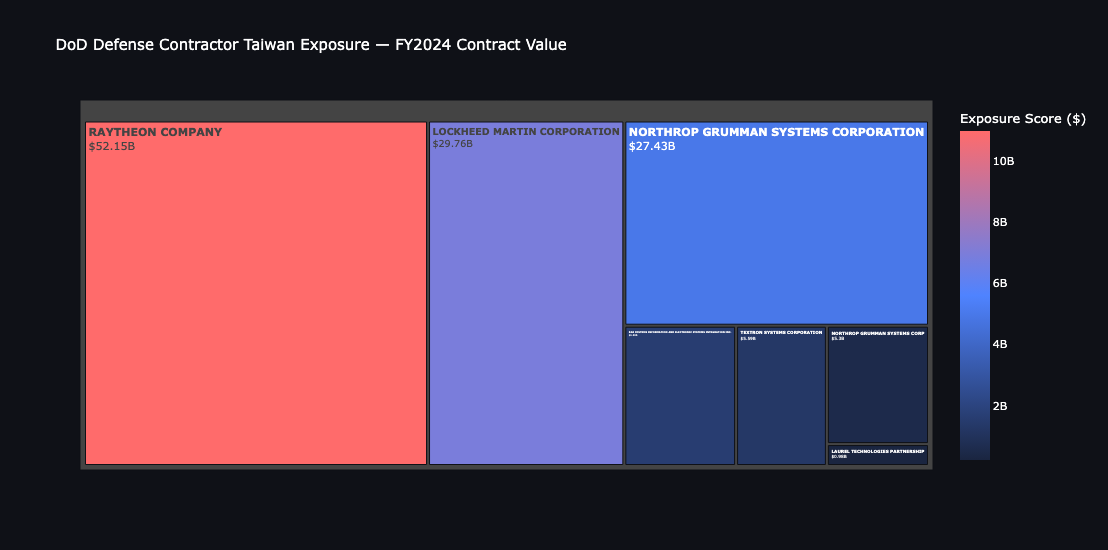

In [14]:
df_defense_agg = df_defense.groupby('program_name').agg(
    contract_value_usd=('contract_value_usd', 'sum'),
    exposure_score=('exposure_score', 'sum'),
    naics_description=('naics_description', 'first')
).reset_index()

df_defense_agg['contract_value_billions'] = (df_defense_agg['contract_value_usd'] / 1e9).round(2)
df_defense_agg['exposure_billions'] = (df_defense_agg['exposure_score'] / 1e9).round(2)
df_defense_agg['taiwan_dependency_pct_display'] = (df_defense_agg['exposure_score'] / df_defense_agg['contract_value_usd'] * 100).round(1)

fig3 = px.treemap(
    df_defense_agg,
    path=['program_name'],
    values='contract_value_usd',
    color='exposure_score',
    color_continuous_scale=['#1a2540', '#4f83ff', '#ff6b6b'],
    title='DoD Defense Contractor Taiwan Exposure — FY2024 Contract Value',
    custom_data=['contract_value_billions', 'exposure_billions',
                 'taiwan_dependency_pct_display', 'naics_description']
)

fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{customdata[0]}B',
    textfont=dict(size=11),
    hovertemplate='<b>%{label}</b><br>' +
                  'Contract Value: $%{customdata[0]}B<br>' +
                  'Exposure Score: $%{customdata[1]}B<br>' +
                  'Effective Taiwan Dependency: %{customdata[2]}%<br>' +
                  'Primary NAICS: %{customdata[3]}<extra></extra>'
)

fig3.update_layout(
    paper_bgcolor='#0f1117',
    font_color='white',
    font_size=11,
    height=550,
    coloraxis_colorbar=dict(title='Exposure Score ($)')
)

fig3.show()

In [15]:
fig3.write_html('output/chart3_defense.html', include_plotlyjs=True)
print("Exported chart3_defense.html")

Exported chart3_defense.html


In [16]:
df_medical = pd.read_csv('data/medical_exposure.csv')
print(df_medical)

  device_category  dependency_score  taiwan_dependency_pct  supply_shock_pct  \
0    Implantables                 5                  0.233              19.8   
1         Imaging                 5                  0.233              19.8   
2      Monitoring                 4                  0.150              12.8   
3     Ventilators                 4                  0.150              12.8   
4     Diagnostics                 3                  0.100               8.5   

   shortage_onset_days patient_impact_severity  
0                   69                Critical  
1                   69                    High  
2                   76                    High  
3                   76                Critical  
4                   81                Moderate  


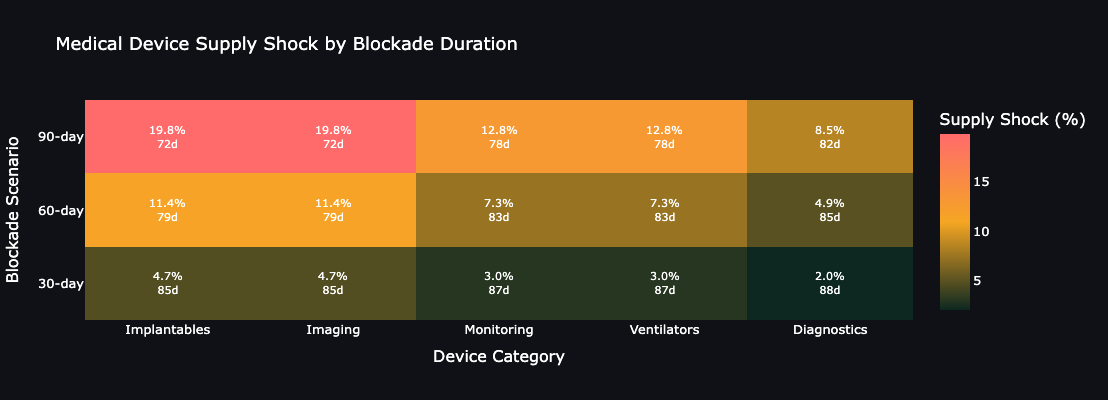

In [17]:
import numpy as np

# Build heatmap matrix — rows = scenarios, cols = device categories
scenarios_list = ['30-day', '60-day', '90-day']
disruption_rates = [0.40, 0.65, 0.85]
buffer_factors = [0.50, 0.25, 0.00]

heatmap_data = []
annotations = []

for i, (scenario, dr, bf) in enumerate(zip(scenarios_list, disruption_rates, buffer_factors)):
    row = []
    for _, dev in df_medical.iterrows():
        shock = dev['taiwan_dependency_pct'] * dr * (1 - bf) * 100
        onset = int(90 * (1 - dev['taiwan_dependency_pct'] * dr * (1 - bf)))
        row.append(round(shock, 1))
        annotations.append(dict(
            x=dev['device_category'],
            y=scenario,
            text=f"{round(shock,1)}%<br>{onset}d",
            showarrow=False,
            font=dict(color='white', size=11)
        ))
    heatmap_data.append(row)

fig4 = go.Figure(go.Heatmap(
    z=heatmap_data,
    x=df_medical['device_category'].tolist(),
    y=scenarios_list,
    colorscale=[[0, '#0d2820'], [0.5, '#f5a623'], [1, '#ff6b6b']],
    text=[[f"{v}%" for v in row] for row in heatmap_data],
    hovertemplate='Device: %{x}<br>Scenario: %{y}<br>Supply Shock: %{z}%<extra></extra>',
    showscale=True,
    colorbar=dict(title='Supply Shock (%)')
))

fig4.update_layout(
    title='Medical Device Supply Shock by Blockade Duration',
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=400,
    xaxis_title='Device Category',
    yaxis_title='Blockade Scenario',
    annotations=annotations
)

fig4.show()

In [18]:
fig4.write_html('output/chart4_medical.html', include_plotlyjs=True)
print("Exported chart4_medical.html")

Exported chart4_medical.html


In [19]:
from plotly.io import to_html

# Get each chart as HTML div (no full page, no plotly.js yet)
chart1_div = to_html(fig, full_html=False, include_plotlyjs=False)
chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)
chart3_div = to_html(fig3, full_html=False, include_plotlyjs=False)
chart4_div = to_html(fig4, full_html=False, include_plotlyjs=False)

dashboard_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>90-Day PLA Naval Blockade: Supply Chain Cascade Analysis</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
  body {{ background: #0f1117; color: #e8eaf6; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; margin: 0; padding: 0; }}
  .header {{ padding: 2rem 2rem 1rem; border-bottom: 1px solid #2e3450; }}
  .header h1 {{ font-size: 20px; font-weight: 600; margin: 0 0 8px 0; color: #e8eaf6; }}
  .header p {{ font-size: 13px; color: #8891b4; margin: 0; max-width: 800px; line-height: 1.6; }}
  .tabs {{ display: flex; gap: 4px; padding: 1rem 2rem 0; border-bottom: 1px solid #2e3450; }}
  .tab {{ padding: 8px 18px; border-radius: 6px 6px 0 0; border: 1px solid #2e3450; border-bottom: none; background: #1a1d27; color: #8891b4; cursor: pointer; font-size: 13px; }}
  .tab.active {{ background: #22263a; color: #e8eaf6; border-color: #3d4466; }}
  .tab:hover {{ background: #22263a; color: #e8eaf6; }}
  .chart-panel {{ display: none; padding: 1.5rem 2rem; }}
  .chart-panel.active {{ display: block; }}
  .assumption-box {{ background: #1a2540; border: 1px solid #2d4080; border-radius: 8px; padding: 1rem 1.5rem; margin-bottom: 1.5rem; font-size: 12px; color: #7ea6ff; line-height: 1.7; }}
  .assumption-box strong {{ color: #e8eaf6; }}
</style>
</head>
<body>

<div class="header">
  <h1>90-Day PLA Naval Blockade: Cascade Effects on US Semiconductor-Dependent Defense and Medical Device Procurement</h1>
  <p>This dashboard models a People's Liberation Army naval blockade of the Taiwan Strait across three durations (30, 60, and 90 days), quantifying supply chain disruption across US semiconductor imports, defense procurement contracts, and medical device categories. All assumptions are explicitly documented. Analysis by Tyler Brown, Penn State University BS Security and Risk Analysis 2026.</p>
</div>

<div class="tabs">
  <div class="tab active" onclick="showTab('t1')">Taiwan Dependency Flow</div>
  <div class="tab" onclick="showTab('t2')">Blockade Scenarios</div>
  <div class="tab" onclick="showTab('t3')">Defense Exposure</div>
  <div class="tab" onclick="showTab('t4')">Medical Devices</div>
</div>

<div id="t1" class="chart-panel active">
  <div class="assumption-box">
    <strong>Methodology:</strong> Flow values represent average annual US imports from Taiwan (2022–2024), sourced from US Census Bureau HTS Chapter 85 data. End-use sector allocation based on TSMC 2023 Annual Report platform revenue breakdown (HPC 43%, Smartphone 38%, IoT 8%, Automotive 6%, Other 5%).
  </div>
  {chart1_div}
</div>

<div id="t2" class="chart-panel">
  <div class="assumption-box">
    <strong>Assumptions:</strong> Supply shock formula: taiwan_import_share × disruption_rate × (1 − inventory_buffer_factor). Disruption rates: 30-day = 40%, 60-day = 65%, 90-day = 85%. Inventory buffer factors: 30-day = 0.50, 60-day = 0.25, 90-day = 0.00. Industry standard semiconductor inventory buffer: 60–90 days (SIA Factbook; chipmaker earnings calls).
  </div>
  {chart2_div}
</div>

<div id="t3" class="chart-panel">
  <div class="assumption-box">
    <strong>Methodology:</strong> Exposure score = contract_value_usd × taiwan_dependency_pct. Taiwan dependency assigned by NAICS code based on semiconductor intensity: NAICS 334511 (navigation/guidance) and 334111 (computers) assigned 23.3% matching 8542 integrated circuit import share. Contract data: USASpending.gov FY2024 DoD contracts, NAICS 334xx.
  </div>
  {chart3_div}
</div>

<div id="t4" class="chart-panel">
  <div class="assumption-box">
    <strong>Methodology:</strong> Medical device semiconductor dependency scored 1–5 by category based on Medtronic and Abbott 10-K supply chain disclosures (SEC EDGAR). Shortage onset = days until supply shock exceeds device inventory buffer. Patient impact severity based on device criticality and availability of manual alternatives.
  </div>
  {chart4_div}
</div>

<script>
function showTab(id) {{
  document.querySelectorAll('.chart-panel').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.tab').forEach(t => t.classList.remove('active'));
  document.getElementById(id).classList.add('active');
  event.target.classList.add('active');
}}
</script>

</body>
</html>"""

with open('output/taiwan_blockade_dashboard.html', 'w') as f:
    f.write(dashboard_html)

print("Dashboard exported to output/taiwan_blockade_dashboard.html")

Dashboard exported to output/taiwan_blockade_dashboard.html


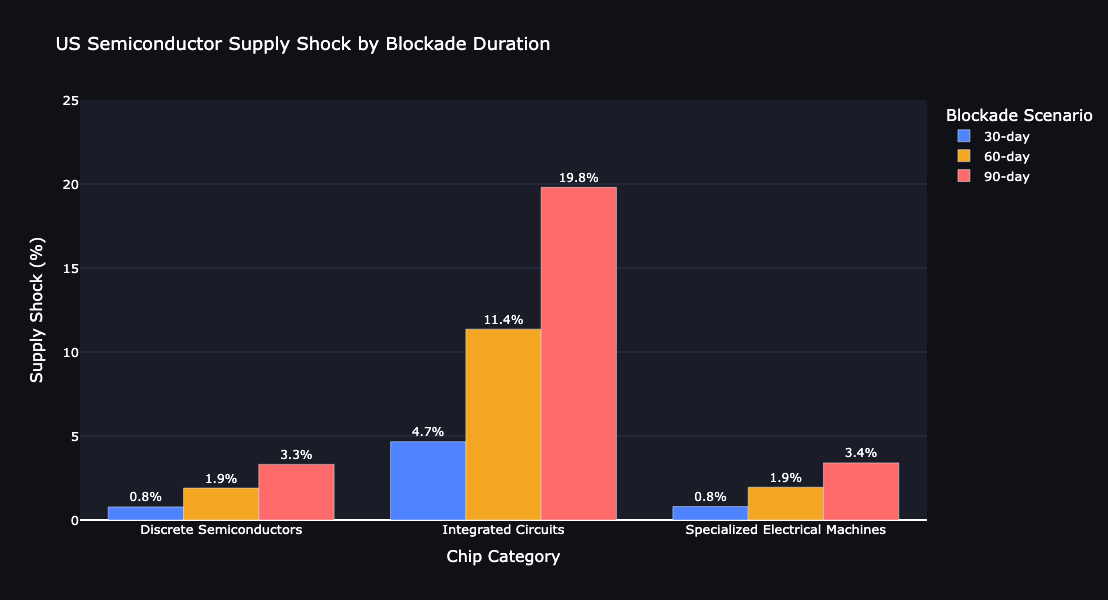

In [20]:
fig2 = px.bar(
    df_scenarios,
    x='chip_category',
    y='supply_shock_pct',
    color='scenario',
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    labels={
        'chip_category': 'Chip Category',
        'supply_shock_pct': 'Supply Shock (%)',
        'scenario': 'Blockade Scenario'
    },
    color_discrete_map={
        '30-day': '#4f83ff',
        '60-day': '#f5a623',
        '90-day': '#ff6b6b'
    }
)

fig2.update_traces(
    texttemplate='%{y:.1f}%',
    textposition='outside',
    textfont=dict(size=12)
)

fig2.update_layout(
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450', range=[0, 25]),
    legend_title='Blockade Scenario'
)

fig2.show()

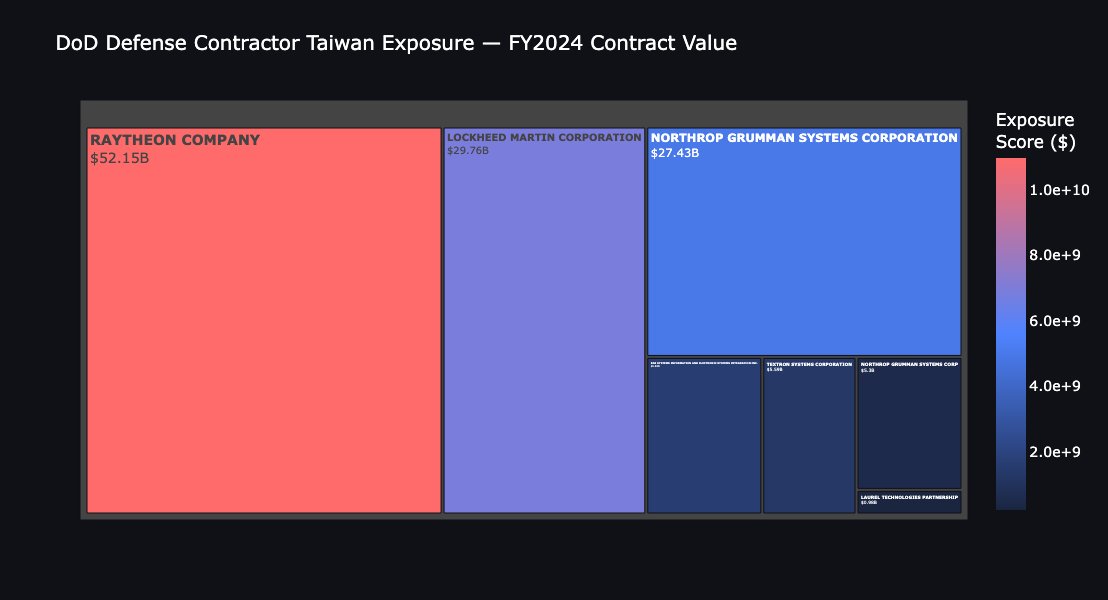

In [21]:
fig3 = px.treemap(
    df_defense_agg,
    path=['program_name'],
    values='contract_value_usd',
    color='exposure_score',
    color_continuous_scale=['#1a2540', '#4f83ff', '#ff6b6b'],
    title='DoD Defense Contractor Taiwan Exposure — FY2024 Contract Value',
    custom_data=['contract_value_billions', 'exposure_billions',
                 'taiwan_dependency_pct_display', 'naics_description']
)

fig3.update_traces(
    texttemplate='<b>%{label}</b><br>$%{customdata[0]}B',
    textfont=dict(size=14),
    hovertemplate='<b>%{label}</b><br>' +
                  'Contract Value: $%{customdata[0]}B<br>' +
                  'Exposure Score: $%{customdata[1]}B<br>' +
                  'Effective Taiwan Dependency: %{customdata[2]}%<br>' +
                  'Primary NAICS: %{customdata[3]}<extra></extra>'
)

fig3.update_layout(
    paper_bgcolor='#0f1117',
    font_color='white',
    font_size=14,
    height=600,
    coloraxis_colorbar=dict(
        title='Exposure<br>Score ($)',
        tickformat='.1e'
    )
)

fig3.show()

In [31]:
from plotly.io import to_html

chart1_div = to_html(fig, full_html=False, include_plotlyjs=False)
chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)
chart3_div = to_html(fig3, full_html=False, include_plotlyjs=False)
chart4_div = to_html(fig4, full_html=False, include_plotlyjs=False)

dashboard_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>90-Day PLA Naval Blockade: Supply Chain Cascade Analysis</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
  body {{ background: #0f1117; color: #e8eaf6; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; margin: 0; padding: 0; }}
  .header {{ padding: 2rem 2rem 1rem; border-bottom: 1px solid #2e3450; }}
  .header h1 {{ font-size: 20px; font-weight: 600; margin: 0 0 8px 0; color: #e8eaf6; }}
  .header p {{ font-size: 13px; color: #8891b4; margin: 0; max-width: 900px; line-height: 1.6; }}
  .tabs {{ display: flex; gap: 4px; padding: 1rem 2rem 0; border-bottom: 1px solid #2e3450; }}
  .tab {{ padding: 8px 18px; border-radius: 6px 6px 0 0; border: 1px solid #2e3450; border-bottom: none; background: #1a1d27; color: #8891b4; cursor: pointer; font-size: 13px; }}
  .tab.active {{ background: #22263a; color: #e8eaf6; border-color: #3d4466; }}
  .tab:hover {{ background: #22263a; color: #e8eaf6; }}
  .chart-panel {{ display: none; padding: 1.5rem 2rem; }}
  .chart-panel.active {{ display: block; }}
  .assumption-box {{ background: #1a2540; border: 1px solid #2d4080; border-radius: 8px; padding: 1rem 1.5rem; margin-bottom: 1.5rem; font-size: 13px; color: #7ea6ff; line-height: 1.7; }}
  .assumption-box strong {{ color: #e8eaf6; }}
</style>
</head>
<body>

<div class="header">
  <h1>90-Day PLA Naval Blockade: Cascade Effects on US Semiconductor-Dependent Defense and Medical Device Procurement</h1>
  <p>This dashboard models a People's Liberation Army naval blockade of the Taiwan Strait across three durations (30, 60, and 90 days), quantifying supply chain disruption across US semiconductor imports, defense procurement contracts, and medical device categories. All assumptions are explicitly documented. Analysis by Tyler Brown, Penn State University BS Security and Risk Analysis 2026.</p>
</div>

<div class="tabs">
  <div class="tab active" onclick="showTab('t1', this)">Taiwan Dependency Flow</div>
  <div class="tab" onclick="showTab('t2', this)">Blockade Scenarios</div>
  <div class="tab" onclick="showTab('t3', this)">Defense Exposure</div>
  <div class="tab" onclick="showTab('t4', this)">Medical Devices</div>
</div>

<div id="t1" class="chart-panel active">
  <div class="assumption-box">
    <strong>Methodology:</strong> Flow values represent average annual US imports from Taiwan (2022–2024), sourced from US Census Bureau HTS Chapter 85 data. End-use sector allocation based on TSMC 2023 Annual Report platform revenue breakdown (HPC 43%, Smartphone 38%, IoT 8%, Automotive 6%, Other 5%).
  </div>
  {chart1_div}
</div>

<div id="t2" class="chart-panel">
  <div class="assumption-box">
    <strong>Assumptions:</strong> Supply shock formula: taiwan_import_share × disruption_rate × (1 − inventory_buffer_factor). Disruption rates: 30-day = 40%, 60-day = 65%, 90-day = 85%. Inventory buffer factors: 30-day = 0.50, 60-day = 0.25, 90-day = 0.00. Industry standard semiconductor inventory buffer: 60–90 days (SIA Factbook; chipmaker earnings calls).
  </div>
  {chart2_div}
</div>

<div id="t3" class="chart-panel">
  <div class="assumption-box">
    <strong>Methodology:</strong> Exposure score = contract_value_usd × taiwan_dependency_pct. Taiwan dependency assigned by NAICS code based on semiconductor intensity: NAICS 334511 (navigation/guidance) and 334111 (computers) assigned 23.3% matching 8542 integrated circuit import share. Contract data: USASpending.gov FY2024 DoD contracts, NAICS 334xx.
  </div>
  {chart3_div}
</div>

<div id="t4" class="chart-panel">
  <div class="assumption-box">
    <strong>Methodology:</strong> Medical device semiconductor dependency scored 1–5 by category based on Medtronic and Abbott 10-K supply chain disclosures (SEC EDGAR). Shortage onset = days until supply shock exceeds device inventory buffer. Patient impact severity based on device criticality and availability of manual alternatives.
  </div>
  {chart4_div}
</div>

<script>
function showTab(id, el) {{
  document.querySelectorAll('.chart-panel').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.tab').forEach(t => t.classList.remove('active'));
  document.getElementById(id).classList.add('active');
  el.classList.add('active');
}}
</script>

</body>
</html>"""

with open('output/taiwan_blockade_dashboard.html', 'w') as f:
    f.write(dashboard_html)

print("Dashboard rebuilt successfully")

Dashboard rebuilt successfully


In [23]:
fig2 = px.bar(
    df_scenarios,
    x='chip_category',
    y='supply_shock_pct',
    color='scenario',
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    labels={
        'chip_category': 'Chip Category',
        'supply_shock_pct': 'Supply Shock (%)',
        'scenario': 'Blockade Scenario'
    },
    color_discrete_map={
        '30-day': '#4f83ff',
        '60-day': '#f5a623',
        '90-day': '#ff6b6b'
    }
)

fig2.update_traces(
    texttemplate=None,
    text=None,
    hovertemplate='<b>%{x}</b><br>Scenario: %{fullData.name}<br>Supply Shock: %{y:.1f}%<extra></extra>'
)

fig2.update_layout(
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450', range=[0, 25]),
    legend_title='Blockade Scenario'
)

chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)
print("fig2 rebuilt")

fig2 rebuilt


In [25]:
print(df_scenarios[['scenario', 'chip_category', 'supply_shock_pct']])

  scenario                    chip_category  supply_shock_pct
0   30-day          Discrete Semiconductors              0.78
1   30-day              Integrated Circuits              4.66
2   30-day  Specialized Electrical Machines              0.80
3   60-day          Discrete Semiconductors              1.90
4   60-day              Integrated Circuits             11.36
5   60-day  Specialized Electrical Machines              1.95
6   90-day          Discrete Semiconductors              3.31
7   90-day              Integrated Circuits             19.80
8   90-day  Specialized Electrical Machines              3.40


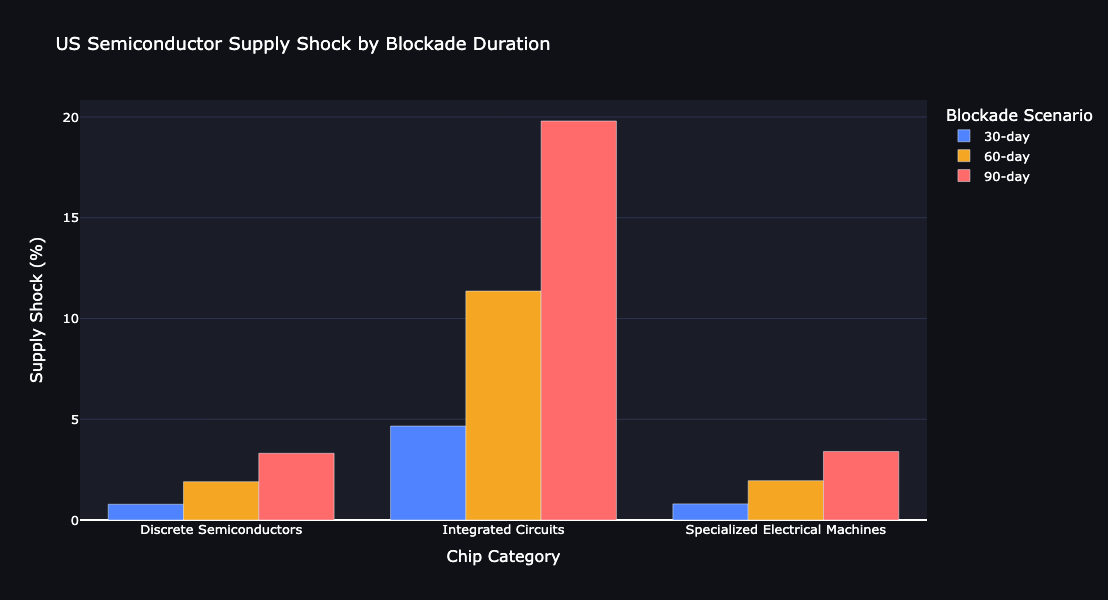

In [26]:
df_scenarios = pd.read_csv('data/scenario_output.csv')

fig2 = px.bar(
    df_scenarios,
    x='chip_category',
    y='supply_shock_pct',
    color='scenario',
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    labels={
        'chip_category': 'Chip Category',
        'supply_shock_pct': 'Supply Shock (%)',
        'scenario': 'Blockade Scenario'
    },
    color_discrete_map={
        '30-day': '#4f83ff',
        '60-day': '#f5a623',
        '90-day': '#ff6b6b'
    }
)

fig2.update_traces(
    hovertemplate='<b>%{x}</b><br>Scenario: %{fullData.name}<br>Supply Shock: %{y:.1f}%<extra></extra>'
)

fig2.update_layout(
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450'),
    legend_title='Blockade Scenario'
)

fig2.show()

In [28]:
print(df_scenarios.dtypes)
print(df_scenarios['supply_shock_pct'].unique())

scenario                         str
hts_code                       int64
chip_category                    str
taiwan_import_share_pct      float64
disruption_rate              float64
inventory_buffer_factor      float64
supply_shock_pct             float64
days_to_critical_shortage      int64
dtype: object
[ 0.78  4.66  0.8   1.9  11.36  1.95  3.31 19.8   3.4 ]


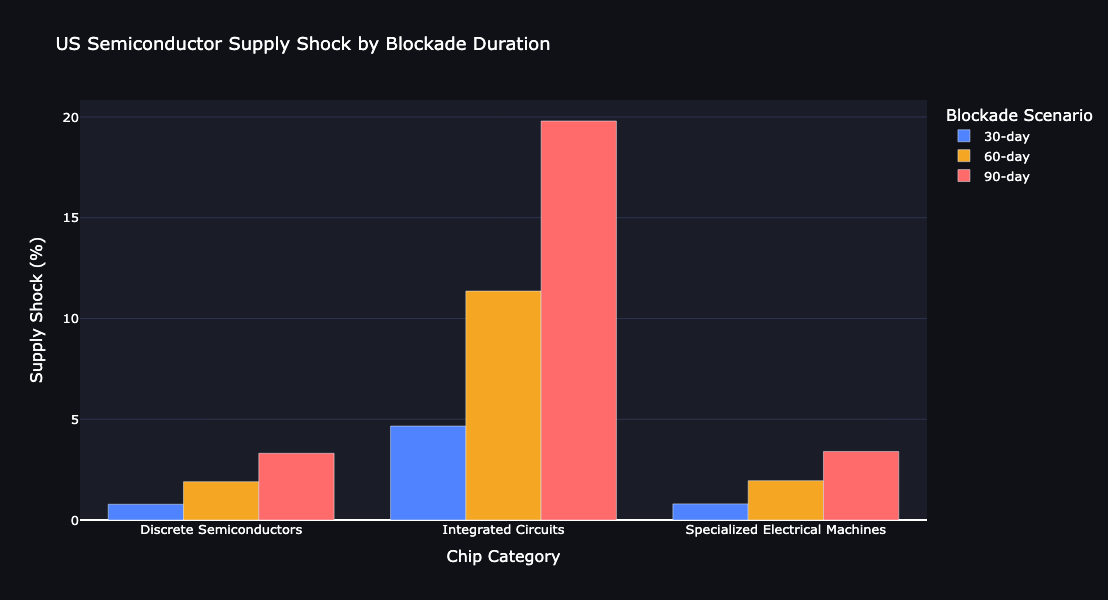

In [29]:
df_scenarios['scenario'] = pd.Categorical(df_scenarios['scenario'], categories=['30-day', '60-day', '90-day'], ordered=True)
df_scenarios = df_scenarios.sort_values(['chip_category', 'scenario'])

fig2 = px.bar(
    df_scenarios,
    x='chip_category',
    y='supply_shock_pct',
    color='scenario',
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    labels={
        'chip_category': 'Chip Category',
        'supply_shock_pct': 'Supply Shock (%)',
        'scenario': 'Blockade Scenario'
    },
    color_discrete_map={
        '30-day': '#4f83ff',
        '60-day': '#f5a623',
        '90-day': '#ff6b6b'
    },
    category_orders={'scenario': ['30-day', '60-day', '90-day']}
)

fig2.update_layout(
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450'),
    legend_title='Blockade Scenario'
)

fig2.show()

In [30]:
chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)
print("fig2 ready")

fig2 ready


In [32]:
from plotly.io import to_html

# Rebuild fig2 with correct data
df_scenarios = pd.read_csv('data/scenario_output.csv')
df_scenarios['scenario'] = pd.Categorical(df_scenarios['scenario'], categories=['30-day', '60-day', '90-day'], ordered=True)
df_scenarios = df_scenarios.sort_values(['chip_category', 'scenario'])

fig2 = px.bar(
    df_scenarios,
    x='chip_category',
    y='supply_shock_pct',
    color='scenario',
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    labels={
        'chip_category': 'Chip Category',
        'supply_shock_pct': 'Supply Shock (%)',
        'scenario': 'Blockade Scenario'
    },
    color_discrete_map={
        '30-day': '#4f83ff',
        '60-day': '#f5a623',
        '90-day': '#ff6b6b'
    },
    category_orders={'scenario': ['30-day', '60-day', '90-day']}
)

fig2.update_layout(
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450'),
    legend_title='Blockade Scenario'
)

# Export all divs
chart1_div = to_html(fig, full_html=False, include_plotlyjs=False)
chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)
chart3_div = to_html(fig3, full_html=False, include_plotlyjs=False)
chart4_div = to_html(fig4, full_html=False, include_plotlyjs=False)

print("All charts ready")
print("fig2 max value check:", df_scenarios['supply_shock_pct'].max())

All charts ready
fig2 max value check: 19.8


In [33]:
dashboard_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>90-Day PLA Naval Blockade: Supply Chain Cascade Analysis</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
  body {{ background: #0f1117; color: #e8eaf6; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; margin: 0; padding: 0; }}
  .header {{ padding: 2rem 2rem 1rem; border-bottom: 1px solid #2e3450; }}
  .header h1 {{ font-size: 20px; font-weight: 600; margin: 0 0 8px 0; color: #e8eaf6; }}
  .header p {{ font-size: 13px; color: #8891b4; margin: 0; max-width: 900px; line-height: 1.6; }}
  .tabs {{ display: flex; gap: 4px; padding: 1rem 2rem 0; border-bottom: 1px solid #2e3450; }}
  .tab {{ padding: 8px 18px; border-radius: 6px 6px 0 0; border: 1px solid #2e3450; border-bottom: none; background: #1a1d27; color: #8891b4; cursor: pointer; font-size: 13px; }}
  .tab.active {{ background: #22263a; color: #e8eaf6; border-color: #3d4466; }}
  .tab:hover {{ background: #22263a; color: #e8eaf6; }}
  .chart-panel {{ display: none; padding: 1.5rem 2rem; }}
  .chart-panel.active {{ display: block; }}
  .assumption-box {{ background: #1a2540; border: 1px solid #2d4080; border-radius: 8px; padding: 1rem 1.5rem; margin-bottom: 1.5rem; font-size: 13px; color: #7ea6ff; line-height: 1.7; }}
  .assumption-box strong {{ color: #e8eaf6; }}
</style>
</head>
<body>

<div class="header">
  <h1>90-Day PLA Naval Blockade: Cascade Effects on US Semiconductor-Dependent Defense and Medical Device Procurement</h1>
  <p>This dashboard models a People's Liberation Army naval blockade of the Taiwan Strait across three durations (30, 60, and 90 days), quantifying supply chain disruption across US semiconductor imports, defense procurement contracts, and medical device categories. All assumptions are explicitly documented. Analysis by Tyler Brown, Penn State University BS Security and Risk Analysis 2026.</p>
</div>

<div class="tabs">
  <div class="tab active" onclick="showTab('t1', this)">Taiwan Dependency Flow</div>
  <div class="tab" onclick="showTab('t2', this)">Blockade Scenarios</div>
  <div class="tab" onclick="showTab('t3', this)">Defense Exposure</div>
  <div class="tab" onclick="showTab('t4', this)">Medical Devices</div>
</div>

<div id="t1" class="chart-panel active">
  <div class="assumption-box">
    <strong>Methodology:</strong> Flow values represent average annual US imports from Taiwan (2022–2024), sourced from US Census Bureau HTS Chapter 85 data. End-use sector allocation based on TSMC 2023 Annual Report platform revenue breakdown (HPC 43%, Smartphone 38%, IoT 8%, Automotive 6%, Other 5%).
  </div>
  {chart1_div}
</div>

<div id="t2" class="chart-panel">
  <div class="assumption-box">
    <strong>Assumptions:</strong> Supply shock formula: taiwan_import_share × disruption_rate × (1 − inventory_buffer_factor). Disruption rates: 30-day = 40%, 60-day = 65%, 90-day = 85%. Inventory buffer factors: 30-day = 0.50, 60-day = 0.25, 90-day = 0.00. Industry standard semiconductor inventory buffer: 60–90 days (SIA Factbook; chipmaker earnings calls).
  </div>
  {chart2_div}
</div>

<div id="t3" class="chart-panel">
  <div class="assumption-box">
    <strong>Methodology:</strong> Exposure score = contract_value_usd × taiwan_dependency_pct. Taiwan dependency assigned by NAICS code based on semiconductor intensity: NAICS 334511 (navigation/guidance) and 334111 (computers) assigned 23.3% matching 8542 integrated circuit import share. Contract data: USASpending.gov FY2024 DoD contracts, NAICS 334xx.
  </div>
  {chart3_div}
</div>

<div id="t4" class="chart-panel">
  <div class="assumption-box">
    <strong>Methodology:</strong> Medical device semiconductor dependency scored 1–5 by category based on Medtronic and Abbott 10-K supply chain disclosures (SEC EDGAR). Shortage onset = days until supply shock exceeds device inventory buffer. Patient impact severity based on device criticality and availability of manual alternatives.
  </div>
  {chart4_div}
</div>

<script>
function showTab(id, el) {{
  document.querySelectorAll('.chart-panel').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.tab').forEach(t => t.classList.remove('active'));
  document.getElementById(id).classList.add('active');
  el.classList.add('active');
}}
</script>

</body>
</html>"""

with open('output/taiwan_blockade_dashboard.html', 'w') as f:
    f.write(dashboard_html)

print("Dashboard exported")

Dashboard exported


In [35]:
import plotly.graph_objects as go
from plotly.io import to_html

scenarios_order = ['30-day', '60-day', '90-day']
colors = {'30-day': '#4f83ff', '60-day': '#f5a623', '90-day': '#ff6b6b'}
categories = ['Discrete Semiconductors', 'Integrated Circuits', 'Specialized Electrical Machines']

df_s = pd.read_csv('data/scenario_output.csv')

fig2 = go.Figure()

for scenario in scenarios_order:
    df_sub = df_s[df_s['scenario'] == scenario].sort_values('chip_category')
    fig2.add_trace(go.Bar(
        name=scenario,
        x=df_sub['chip_category'],
        y=df_sub['supply_shock_pct'],
        marker_color=colors[scenario],
        hovertemplate='<b>%{x}</b><br>Scenario: ' + scenario + '<br>Supply Shock: %{y:.1f}%<extra></extra>'
    ))

fig2.update_layout(
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450', title='Supply Shock (%)'),
    xaxis=dict(title='Chip Category'),
    legend_title='Blockade Scenario'
)

chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)

# Verify it has data
import re
numbers = re.findall(r'"y":\[([^\]]+)\]', chart2_div)
print("Data check:", numbers[:3])

Data check: []


In [36]:
print(len(chart2_div))
print(chart2_div[:500])

8739
<div style="height:600px; width:100%;">                            <div id="7879d702-6dec-456f-b269-fc2581dde909" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script>                window.PLOTLYENV=window.PLOTLYENV || {};                                if (document.getElementById("7879d702-6dec-456f-b269-fc2581dde909")) {                    Plotly.newPlot(                        "7879d702-6dec-456f-b269-fc2581dde909",                        [{"hovertemplate":"\u0


In [37]:
import plotly.graph_objects as go
from plotly.io import to_html
import pandas as pd

# Rebuild fig2
df_s = pd.read_csv('data/scenario_output.csv')
scenarios_order = ['30-day', '60-day', '90-day']
colors = {'30-day': '#4f83ff', '60-day': '#f5a623', '90-day': '#ff6b6b'}

fig2 = go.Figure()
for scenario in scenarios_order:
    df_sub = df_s[df_s['scenario'] == scenario].sort_values('chip_category')
    fig2.add_trace(go.Bar(
        name=scenario,
        x=df_sub['chip_category'],
        y=df_sub['supply_shock_pct'],
        marker_color=colors[scenario],
        hovertemplate='<b>%{x}</b><br>Scenario: ' + scenario + '<br>Supply Shock: %{y:.1f}%<extra></extra>'
    ))
fig2.update_layout(
    barmode='group',
    title='US Semiconductor Supply Shock by Blockade Duration',
    paper_bgcolor='#0f1117',
    plot_bgcolor='#1a1d27',
    font_color='white',
    font_size=13,
    height=600,
    yaxis=dict(gridcolor='#2e3450', title='Supply Shock (%)'),
    xaxis=dict(title='Chip Category'),
    legend_title='Blockade Scenario'
)

# Generate all divs
chart1_div = to_html(fig, full_html=False, include_plotlyjs=False)
chart2_div = to_html(fig2, full_html=False, include_plotlyjs=False)
chart3_div = to_html(fig3, full_html=False, include_plotlyjs=False)
chart4_div = to_html(fig4, full_html=False, include_plotlyjs=False)

# Write dashboard
dashboard_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>90-Day PLA Naval Blockade: Supply Chain Cascade Analysis</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
  body {{ background: #0f1117; color: #e8eaf6; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; margin: 0; padding: 0; }}
  .header {{ padding: 2rem 2rem 1rem; border-bottom: 1px solid #2e3450; }}
  .header h1 {{ font-size: 20px; font-weight: 600; margin: 0 0 8px 0; color: #e8eaf6; }}
  .header p {{ font-size: 13px; color: #8891b4; margin: 0; max-width: 900px; line-height: 1.6; }}
  .tabs {{ display: flex; gap: 4px; padding: 1rem 2rem 0; border-bottom: 1px solid #2e3450; }}
  .tab {{ padding: 8px 18px; border-radius: 6px 6px 0 0; border: 1px solid #2e3450; border-bottom: none; background: #1a1d27; color: #8891b4; cursor: pointer; font-size: 13px; }}
  .tab.active {{ background: #22263a;

_IncompleteInputError: incomplete input (297220377.py, line 40)